# 03 — Exploratory Data Analysis

Distributions, coverage, and geometric characteristics of the pass dataset.

In [8]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from mplsoccer import Pitch
except ImportError:
    Pitch = None


## 1. Load processed data

In [2]:

pass_instances = pd.read_parquet("../data/processed/pass_instances.parquet")
frames = pd.read_parquet("../data/processed/frames_360.parquet")
print(f"Pass instances: {len(pass_instances):,}")
print(f"360 frame rows: {len(frames):,}")
pass_instances.head()


Pass instances: 50,688
360 frame rows: 3,084,876


,match_id,competition_id,season_id,event_uuid,possession_id,team_name,player_name,pass_recipient_name,minute,second,...,n_visible_teammates,n_visible_opponents,line_break,strict_line_break,loose_line_break,threat_gain,shot_within_k,final_third_entry_k,box_entry_k,dangerous_progression_k
0,3764440,<NA>,<NA>,df248b0b-baeb-4bf0-9557-062682814138,2,Elche,José Raúl Gutiérrez Parejo,Gonzalo Cacicedo Verdú,0,1,...,<NA>,<NA>,NaN,<NA>,<NA>,0.015696,False,False,False,False
1,3764440,<NA>,<NA>,934bd267-dcf8-4f0f-aa6b-ce68cbe9397d,2,Elche,Gonzalo Cacicedo Verdú,José Manuel Sánchez Guillén,0,4,...,<NA>,<NA>,NaN,<NA>,<NA>,0.113793,False,False,False,False
2,3764440,<NA>,<NA>,af1686ea-3488-43f5-a4f7-a31237210a4e,2,Elche,José Manuel Sánchez Guillén,Gonzalo Cacicedo Verdú,0,7,...,<NA>,<NA>,NaN,<NA>,<NA>,0.054513,False,True,False,True
3,3764440,<NA>,<NA>,8e6876df-38ab-4a3d-bf42-60d2b06c0804,2,Elche,Gonzalo Cacicedo Verdú,Lucas Ariel Boyé,0,12,...,<NA>,<NA>,NaN,<NA>,<NA>,-0.146552,False,True,False,True
4,3764440,<NA>,<NA>,380c420c-1710-4b09-a46a-6ea295bdaa6e,3,Barcelona,Marc-André ter Stegen,Samuel Yves Umtiti,0,23,...,<NA>,<NA>,NaN,<NA>,<NA>,-0.454868,False,False,False,False


## 2. Pass length and angle distributions

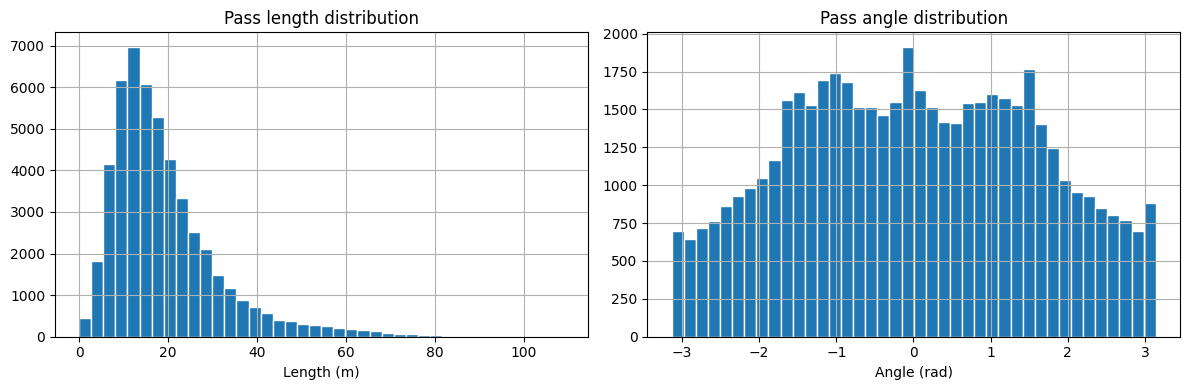

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pass_instances["pass_length"].hist(bins=40, ax=axes[0], edgecolor="white")
axes[0].set_title("Pass length distribution")
axes[0].set_xlabel("Length (m)")
pass_instances["pass_angle"].hist(bins=40, ax=axes[1], edgecolor="white")
axes[1].set_title("Pass angle distribution")
axes[1].set_xlabel("Angle (rad)")
plt.tight_layout()
plt.show()


## 3. Visible player count distributions

In [4]:

has360 = pass_instances[pass_instances["has_360"]]
print(f"Passes with 360 data: {len(has360):,} / {len(pass_instances):,} ({len(has360)/len(pass_instances):.1%})")
has360[["n_visible_players", "n_visible_teammates", "n_visible_opponents"]].describe()


Passes with 360 data: 26,515 / 50,688 (52.3%)


,n_visible_players,n_visible_teammates,n_visible_opponents
count,26515.0,26515.0,26515.0
mean,15.105035,7.565642,7.539393
std,3.473661,1.767492,2.224226
min,1.0,1.0,0.0
25%,13.0,6.0,6.0
50%,16.0,8.0,8.0
75%,18.0,9.0,9.0
max,21.0,11.0,11.0


## 4. Pass origin / destination heatmaps

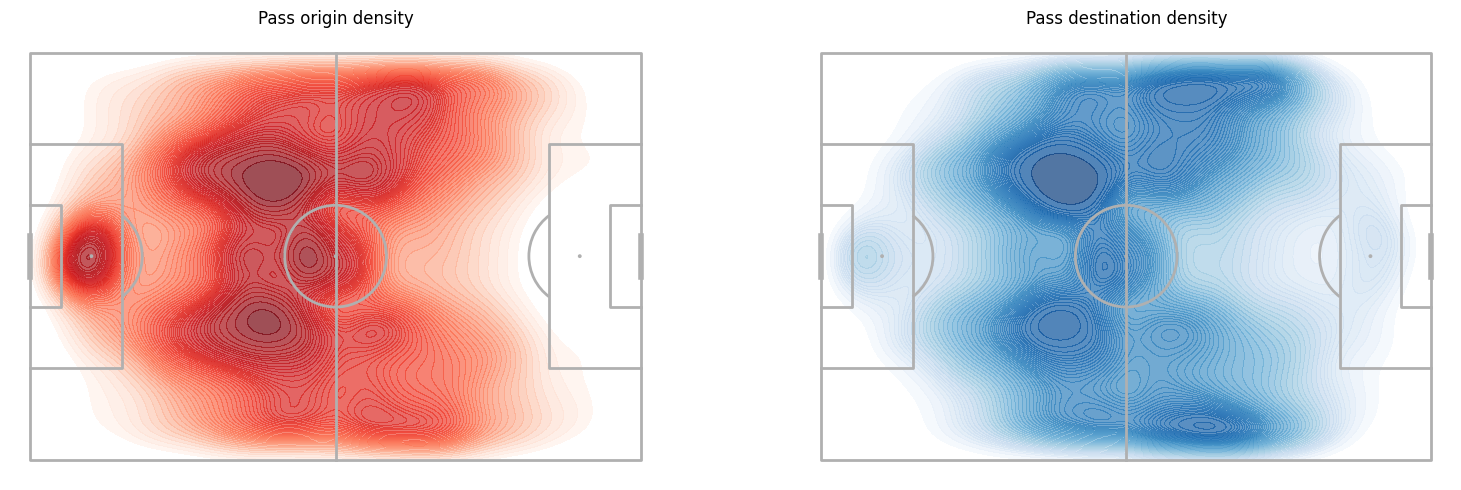

In [5]:

if Pitch is not None:
    pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Origin heatmap
    pitch.draw(ax=axes[0])
    pitch.kdeplot(pass_instances["start_x"], pass_instances["start_y"],
                  ax=axes[0], cmap="Reds", fill=True, levels=50, alpha=0.7)
    axes[0].set_title("Pass origin density")

    # Destination heatmap
    pitch.draw(ax=axes[1])
    pitch.kdeplot(pass_instances["end_x"], pass_instances["end_y"],
                  ax=axes[1], cmap="Blues", fill=True, levels=50, alpha=0.7)
    axes[1].set_title("Pass destination density")

    plt.tight_layout()
    plt.show()
else:
    print("mplsoccer not installed — skipping pitch heatmaps")


## 5. 360 coverage summary

360 coverage by competition:
Empty DataFrame
Columns: [competition_id, total, with_360, pct_360]
Index: []


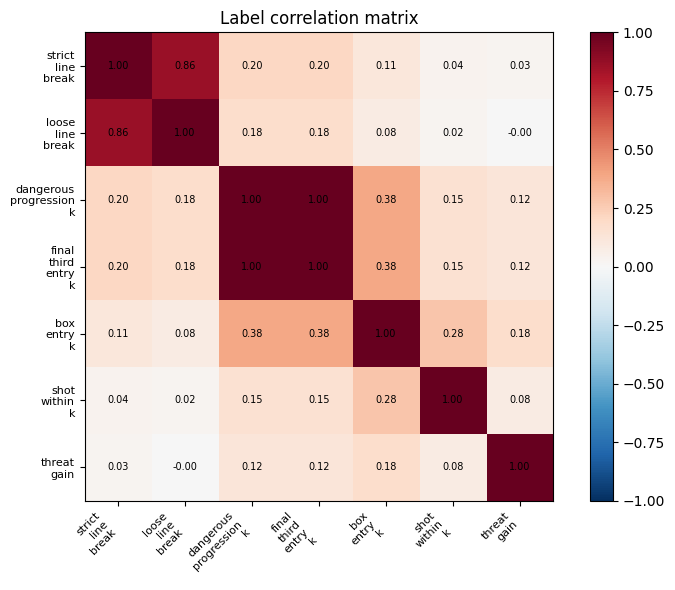

In [6]:

coverage = pass_instances.groupby("competition_id").agg(
    total=("has_360", "count"),
    with_360=("has_360", "sum"),
    pct_360=("has_360", "mean"),
).reset_index()
coverage["pct_360"] = (coverage["pct_360"] * 100).round(1)
print("360 coverage by competition:")
print(coverage.to_string(index=False))

# Label correlation matrix
label_cols = ["strict_line_break", "loose_line_break",
              "dangerous_progression_k", "final_third_entry_k",
              "box_entry_k", "shot_within_k", "threat_gain"]
corr = pass_instances[label_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(label_cols)))
ax.set_yticks(range(len(label_cols)))
ax.set_xticklabels([c.replace("_", "\n") for c in label_cols], fontsize=8, rotation=45, ha="right")
ax.set_yticklabels([c.replace("_", "\n") for c in label_cols], fontsize=8)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        val = corr.iloc[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=ax)
ax.set_title("Label correlation matrix")
plt.tight_layout()
plt.show()
